In [46]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Layer
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

In [47]:
# Dataset sintentico

frases = [
    "la pelicula fue excelente",
    "la pelicula fue maravillosa",
    "la actuacion fue brillante",
    "el guion fue interesante",
    "la historia fue emotiva",
    "la direccion fue impecable",
    "el final fue sorprendente",
    "la cinematografia fue hermosa",
    "la musica fue extraordinaria",
    "la experiencia fue agradable",

    "la pelicula fue terrible",
    "la pelicula fue aburrida",
    "la actuacion fue mala",
    "el guion fue confuso",
    "la historia fue mediocre",
    "la direccion fue pobre",
    "el final fue decepcionante",
    "la cinematografia fue mala",
    "la musica fue molesta",
    "la experiencia fue desagradable",

    "la pelicula fue lenta pero excelente",
    "la historia fue simple pero emotiva",
    "la actuacion fue rara pero brillante",
    "el inicio fue lento pero el final fue sorprendente",
    "la musica fue extraña pero hermosa",

    "la pelicula fue bonita pero aburrida",
    "la cinematografia fue hermosa pero el guion fue terrible",
    "la actuacion fue buena pero la historia fue mediocre",
    "el inicio fue interesante pero el final fue decepcionante",
    "la musica fue agradable pero la experiencia fue desagradable"
]

etiquetas = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
             1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

df= pd.DataFrame({
    "frase": frases,
    "etiqueta": etiquetas
})

In [48]:
#Dividir en train y test

X = df['frase'].tolist()
y = df['etiqueta'].tolist()

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.25,
                                                    random_state=42,
                                                    stratify=y)

In [49]:
# Tokenizacion
tokenizer = Tokenizer(oov_token="<OOV>")

tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index

vocab_size = len(word_index) + 1

# Scuencias de numeros
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = max([len(seq) for seq in X_train_seq])

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

y_train_np = np.array(y_train)
y_test_np = np.array(y_test)
print(vocab_size)

37


In [50]:
# Capa de atencion

class AttentionPooling(Layer):

  def __init__(self, **kwargs):
    super(AttentionPooling, self).__init__(**kwargs)

  def build(self, input_shape):
    hidden_dim= input_shape[-1]

    # W_attention transforma cada estado oculto para calcular relevancia
    self.W_attention = self.add_weight(
        name="W_attention",
        shape=(hidden_dim, hidden_dim),
        initializer="glorot_uniform",
        trainable=True
    )

    # v_attention proyecta cada estado tranformado a un scor escalar
    self.v_attention = self.add_weight(
        name="v_attention",
        shape=(hidden_dim, 1),
        initializer="glorot_uniform",
        trainable=True
    )

    # b_attention es un sesgo para la transformacion
    self.b_attention = self.add_weight(
        name="b_attention",
        shape=(hidden_dim,),
        initializer="zeros",
        trainable=True
    )

    # Cerramos construccion
    super(AttentionPooling, self).build(input_shape)

  def call(self, hidden_states):

    # Paso 1:
    # Transformar cada estado oculto con una capata tipo tanh
    score_features = tf.tanh(
        tf.tensordot(hidden_states, self.W_attention, axes=1) + self.b_attention
    )

    # Paso 2:
    # Convertimos cada estado transformado en un score escalar
    # Forma (batch, timesteps, 1)
    raw_scores = tf.tensordot(score_features, self.v_attention, axes=1)

    # Paso 3:
    # Quitamos la ultima dimension para obtener la forma:
    # (batch, timesteps)
    raw_scores = tf.squeeze(raw_scores, axis=-1)

    # Paso 4:
    # Softmax convierte los scores en pesos de atención.
    # Cada frase tendra pesos que suman 1.
    attention_weights = tf.nn.softmax(raw_scores, axis=1)

    # Paso 5:
    # Expandir la dimension para poder multiplicar por hidden_states
    # Forma (batch, timesteps, 1)
    attention_weights_expanded = tf.expand_dims(attention_weights, axis=-1)

    # Paso 6:
    # Multipolicamos cada estado por su peso
    weighted_hidden_states = hidden_states * attention_weights_expanded

    # Paso 7:
    # Sumamos todos los estados ponderdos.
    # Forma (batch, hidden_dim)
    context_vector = tf.reduce_sum(weighted_hidden_states, axis=1)

    # Regresamos tanto el contexto como los pesos
    return context_vector, attention_weights

In [51]:
# Contruir el modelo RNN + atencion

# Dimension del embedding
embeddin_dim=32

# Numero de unidades GRU
gru_units=64

# Entrada del modelo
input_layer = Input (shape=(max_len,), name="entrada_tokens")

# Embedding convierte lindices en vectores
embedding_layer = Embedding(input_dim=vocab_size, output_dim=embeddin_dim, mask_zero= False,
                            name="embedding")(input_layer)
# GRU
gru_ouputs = GRU(gru_units,
                 return_sequences=True,
                 name="gru_encoder")(embedding_layer)

# Aplicamos atencion
context_vector, attention_weights = AttentionPooling(name="attention_pooling")(gru_ouputs)

classification_output = Dense(
    1,
    activation="sigmoid",
    name="salida_clasificacion"
)(context_vector)

modelo = Model(inputs=input_layer,
               outputs = classification_output,
               name="modelo_gru_con_atencion")

modelo.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

modelo.summary()

Model: "modelo_gru_con_atencion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_tokens (InputLayer)     │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 9, 32)          │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_encoder (GRU)               │ (None, 9, 64)          │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_pooling               │ [(None, 64), (None,    │         4,224 │
│ (AttentionPooling)              │ 9)]                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_clasificacion (Dense)    │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,289 (94.88 KB)

 Trainable params: 24,289 (94.88 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Entrenamiento del modelo

historial = modelo.fit(
    X_train_pad,
    y_train_np,
    epochs=60,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

<function matplotlib.pyplot.show(close=None, block=None)>

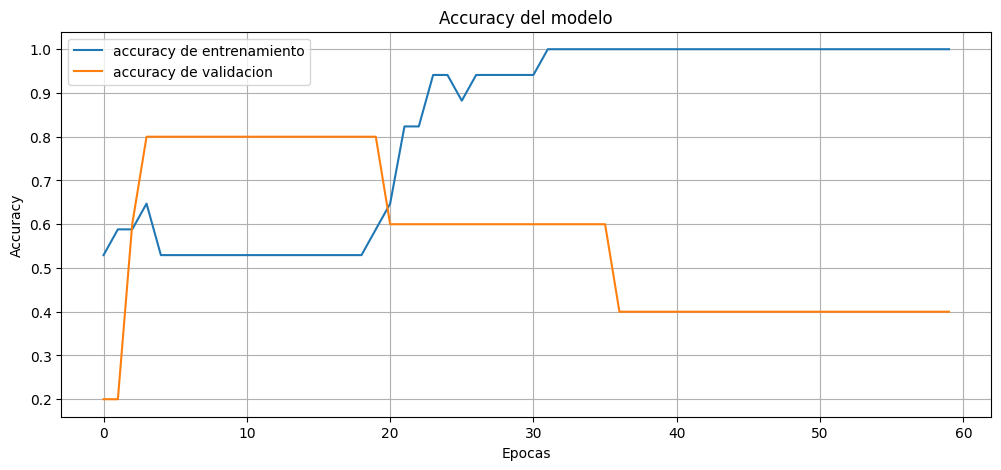

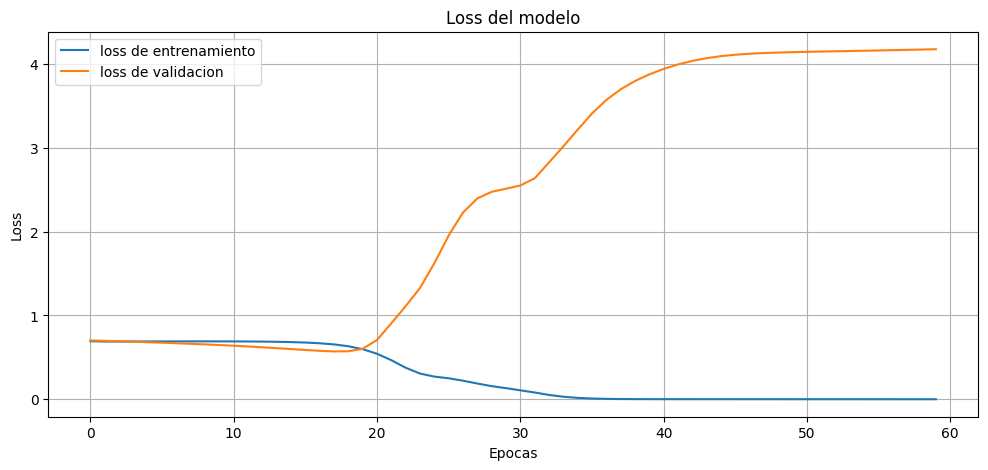

In [53]:
# Graficas de entrenamiento

# Accuracy
plt.figure(figsize=(12,5))
plt.plot(historial.history["accuracy"], label="accuracy de entrenamiento")
plt.plot(historial.history["val_accuracy"], label="accuracy de validacion")
plt.title("Accuracy del modelo")
plt.xlabel("Epocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show

# Loss
plt.figure(figsize=(12,5))
plt.plot(historial.history["loss"], label="loss de entrenamiento")
plt.plot(historial.history["val_loss"], label="loss de validacion")
plt.title("Loss del modelo")
plt.xlabel("Epocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show

In [54]:
# Modelo para extraer pesos de atencion

modelo_atencion = Model(
    inputs=input_layer,
    outputs=[classification_output, attention_weights],
    name="modelo_para_ver_atencion"
)

In [58]:
# Funcion para interpretar una frase

def interpretar_frase(frase, tokenizer, modelo_atencion, max_len):

  secuencia= tokenizer.texts_to_sequences([frase])

  secuencia_pad = pad_sequences(
      secuencia,
      maxlen=max_len,
      padding="post"
  )

  prediccion, pesos_atencion = modelo_atencion.predict(secuencia_pad, verbose=0)

  probabilidad_positiva = prediccion[0][0]

  pesos = pesos_atencion[0]

  palabras = frase.split()

  # Tomamos solo los pesos correspondientes a palabras reales
  pesos_reales = pesos[:len(palabras)]

  print("Frase:", frase)
  print(f"Probabilidad de clase positiva: {probabilidad_positiva:.4f}")

  if  probabilidad_positiva >= 0.5:
    print("Clasificacion: Positiva")
  else:
    print("Clasificacion: Negativa")

  print("\nPesos de atencion:")

  tabla = pd.DataFrame({
      "palabra": palabras,
      "peso_atencion": pesos_reales
  })

  tabla_ordenada = tabla.sort_values(
      by="peso_atencion",
      ascending=False
  )

  print(tabla_ordenada)

  plt.figure(figsize=(10,4))
  plt.bar(palabras, pesos_reales)
  plt.title("Pesos de atencion por palabra")
  plt.xlabel("Palabras")
  plt.ylabel("Peso de atencion")
  plt.xticks(rotation=45)
  plt.grid(True)
  plt.show()

  return tabla

Frase: la pelicula fue excelente
Probabilidad de clase positiva: 0.9999
Clasificacion: Positiva

Pesos de atencion:
     palabra  peso_atencion
2        fue       0.011225
3  excelente       0.009401
0         la       0.008555
1   pelicula       0.008479


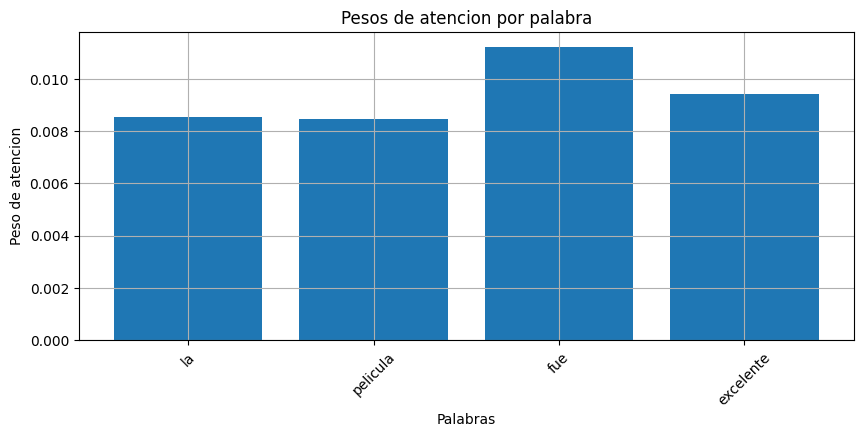

------------------------------------------------------------------------------------------
Frase: la pelicula fue terrible
Probabilidad de clase positiva: 0.0007
Clasificacion: Negativa

Pesos de atencion:
    palabra  peso_atencion
3  terrible       0.002656
2       fue       0.001202
0        la       0.000916
1  pelicula       0.000908


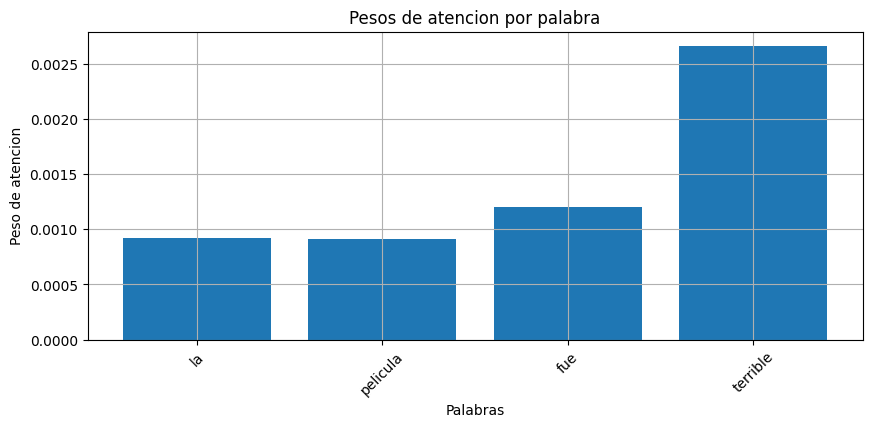

------------------------------------------------------------------------------------------
Frase: la cinematografia fue hermosa pero el guion fue terrible
Probabilidad de clase positiva: 0.0002
Clasificacion: Negativa

Pesos de atencion:
          palabra  peso_atencion
8        terrible       0.261534
7             fue       0.260600
6           guion       0.226224
5              el       0.157274
4            pero       0.072798
3         hermosa       0.016881
2             fue       0.003169
1  cinematografia       0.001040
0              la       0.000478


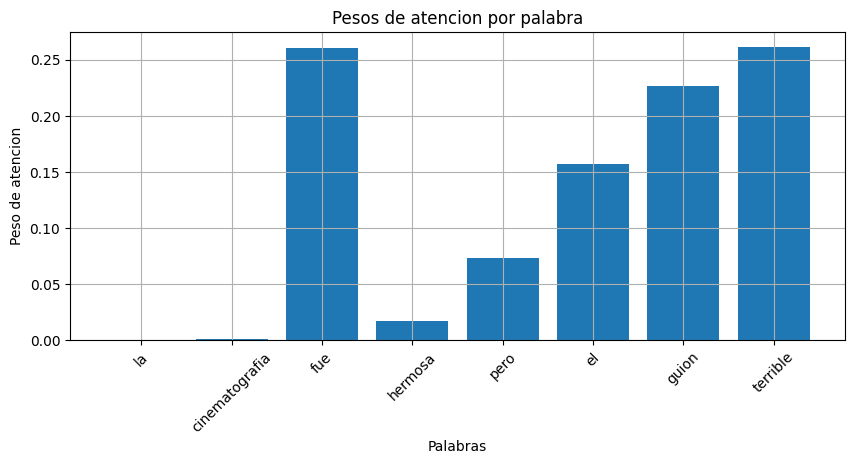

------------------------------------------------------------------------------------------
Frase: la actuacion fue buena pero la historia fue mediocre
Probabilidad de clase positiva: 0.0764
Clasificacion: Negativa

Pesos de atencion:
     palabra  peso_atencion
8   mediocre       0.475223
7        fue       0.157857
6   historia       0.090994
5         la       0.063209
4       pero       0.052521
3      buena       0.046593
2        fue       0.044003
1  actuacion       0.037103
0         la       0.032497


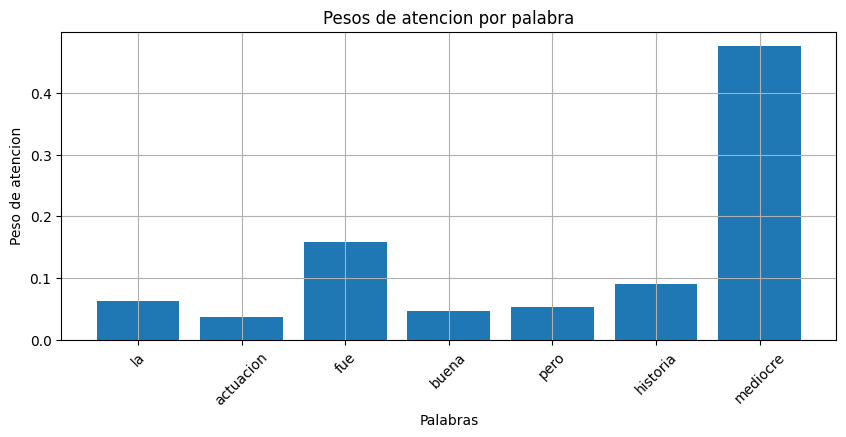

------------------------------------------------------------------------------------------
Frase: la pelicula fue lenta pero excelente
Probabilidad de clase positiva: 0.2512
Clasificacion: Negativa

Pesos de atencion:
     palabra  peso_atencion
5  excelente       0.104411
4       pero       0.098345
3      lenta       0.076951
2        fue       0.068132
0         la       0.051928
1   pelicula       0.051463


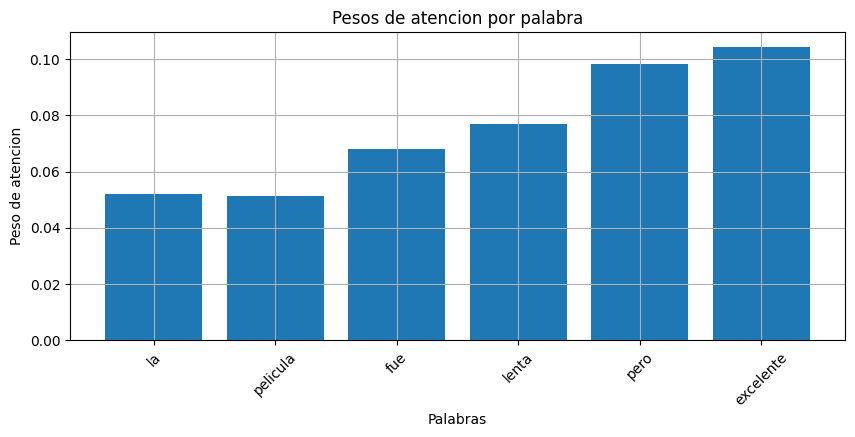

------------------------------------------------------------------------------------------


In [59]:
# Probar frases nuevas

frases_prueba=[
    "la pelicula fue excelente",
    "la pelicula fue terrible",
    "la cinematografia fue hermosa pero el guion fue terrible",
    "la actuacion fue buena pero la historia fue mediocre",
    "la pelicula fue lenta pero excelente"
]

for frase in frases_prueba:
  interpretar_frase(
      frase=frase,
      tokenizer=tokenizer,
      modelo_atencion=modelo_atencion,
      max_len=max_len
  )
  print("-"*90)